<a href="https://colab.research.google.com/github/himanshu1kk/myrepo/blob/main/catsbsdogsclassification1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("salader/dogs-vs-cats")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/dogs-vs-cats


In [4]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/


In [5]:
!chmod 600 ~/.kaggle/kaggle.json


In [6]:
!kaggle datasets download -d salader/dogs-vs-cats


Dataset URL: https://www.kaggle.com/datasets/salader/dogs-vs-cats
License(s): unknown
100% 1.06G/1.06G [00:09<00:00, 181MB/s]
100% 1.06G/1.06G [00:09<00:00, 116MB/s]


In [7]:
import zipfile
zip_ref = zipfile.ZipFile('/content/dogs-vs-cats.zip','r')
zip_ref.extractall('/content')
zip_ref.close()

In [8]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Conv2D , MaxPooling2D ,Flatten,Dropout , BatchNormalization

In [9]:
#generators didvedes the data in the batches so a batch of image is loaded in the RAM
train_ds = keras.utils.image_dataset_from_directory(
    directory  = '/content/dogs_vs_cats/train',
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 32,
    image_size = (256,256)

)

validation_ds = keras.utils.image_dataset_from_directory(
    directory  = '/content/dogs_vs_cats/test',
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 32,
    image_size = (256,256)

)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


In [10]:
#normalize - we want this ki sari pixels value 0-1 ke beech m ho
def process(image,label):
  image = tf.cast(image/255,tf.float32)
  return image,label
train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)


In [11]:
#create CNN model

model = Sequential()
#kernel_size = filter size
model.add(Conv2D(32,kernel_size=(3,3),padding = 'valid',activation='relu',input_shape =(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size =(2,2),strides = 2, padding = 'valid'))

model.add(Conv2D(64,kernel_size =(3,3),padding = 'valid',activation='relu',input_shape =(256,256,3)))
model.add(BatchNormalization())

model.add(MaxPooling2D(pool_size =(2,2),strides = 2, padding = 'valid'))

model.add(Conv2D(128,kernel_size = (3,3),padding = 'valid',activation='relu',input_shape =(256,256,3)))
model.add(BatchNormalization())

model.add(MaxPooling2D(pool_size =(2,2),strides = 2, padding = 'valid'))


model.add(Flatten())

model.add(Dense(128 , activation = 'relu'))
model.add(Dropout(0.1))
model.add(Dense(64 , activation = 'relu'))
model.add(Dropout(0.1))

model.add(Dense(1, activation = 'sigmoid'))

model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,193 (56.64 MB)

 Trainable params: 14,847,745 (56.64 MB)

 Non-trainable params: 448 (1.75 KB)

In [12]:
model.compile(optimizer = 'adam' , loss = 'binary_crossentropy', metrics = ['accuracy'])


In [13]:
history = model.fit(train_ds , epochs = 10  , validation_data = validation_ds)


Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 60s 79ms/step - accuracy: 0.5638 - loss: 2.1084 - val_accuracy: 0.6500 - val_loss: 0.6186
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 47s 75ms/step - accuracy: 0.6753 - loss: 0.6083 - val_accuracy: 0.6178 - val_loss: 0.7017
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 75ms/step - accuracy: 0.7389 - loss: 0.5235 - val_accuracy: 0.7506 - val_loss: 0.5073
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 75ms/step - accuracy: 0.8023 - loss: 0.4380 - val_accuracy: 0.6196 - val_loss: 0.9495
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 51s 82ms/step - accuracy: 0.8234 - loss: 0.3980 - val_accuracy: 0.8114 - val_loss: 0.4163
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 51s 82ms/step - accuracy: 0.8639 - loss: 0.3184 - val_accuracy: 0.7960 - val_loss: 0.4824
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 78s 75ms/step - accuracy: 0.8985 - loss: 0.2453 - val_accuracy: 0.7992 - val_loss: 0.5459
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 46s 74ms/step - accuracy: 0.9365 - loss: 0.1615 - 

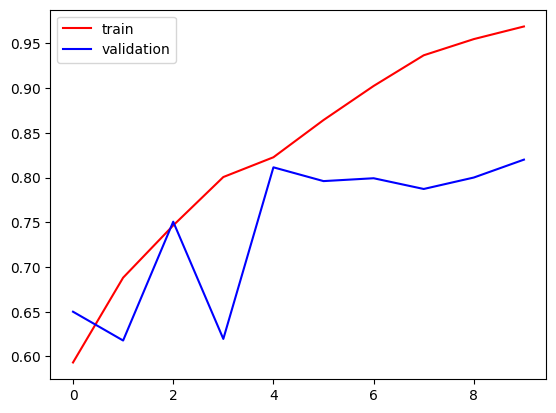

In [14]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'],color = 'red',label = 'train')
plt.plot(history.history['val_accuracy'],color = 'blue', label = 'validation')

plt.legend()
plt.show()

In [15]:
#we cann see the validation accuracy dec but the trainaccuracy inc so this seems to be an overfiiting
#ays to reduce the overfitting

#add moe data
#data augementation
#l1/l2 reguklarixation
#dropout
#batch normalization

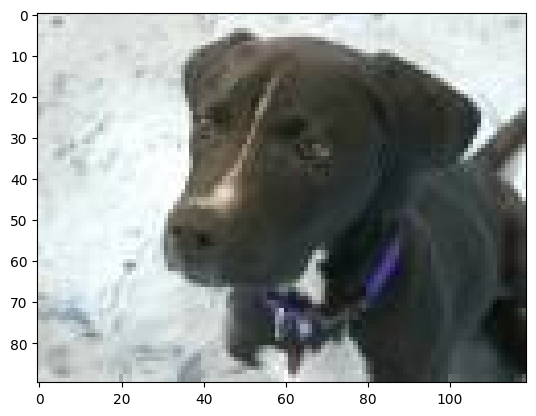

In [16]:
import cv2

test_img = cv2.imread("/content/dogs_vs_cats/test/dogs/dog.3088.jpg")
plt.imshow(test_img)

In [17]:
test_img.shape

(90, 119, 3)

In [18]:
test_img = cv2.resize(test_img,(256,256))

In [19]:
test_input = test_img.reshape((1,256,256,3))

model.predict(test_input)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


array([[1.]], dtype=float32)

In [21]:
!pip install pyngrok
from pyngrok import ngrok
ngrok.set_auth_token("2yDh9lkKOKekkoccoYtHHapkAPr_7CGGyznnbvEM91UNd1jnP")  # Optional (for longer-lived tunnels)
public_url = ngrok.connect(8000)
print(" * Public URL for Frontend:", public_url)

 * Public URL for Frontend: NgrokTunnel: "https://20f0-34-87-0-97.ngrok-free.app" -> "http://localhost:8000"


In [23]:
!pip install pyngrok fastapi uvicorn python-multipart pillow tensorflow

In [24]:
model.save('cat_dog_classifier.h5')

In [ ]:
# ======================
# 5. Set Up FastAPI Backend (FIXED)
# ======================
!pip install nest_asyncio
import nest_asyncio
nest_asyncio.apply()

from fastapi import FastAPI, UploadFile, File
from fastapi.middleware.cors import CORSMiddleware
from PIL import Image
import numpy as np
import io
from pyngrok import ngrok
import uvicorn

app = FastAPI()

# CORS Configuration
app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_methods=["*"],
    allow_headers=["*"],
)

# Load model
model = tf.keras.models.load_model('cat_dog_classifier.h5')

@app.post("/predict")
async def predict(file: UploadFile = File(...)):
    contents = await file.read()
    image = Image.open(io.BytesIO(contents)).resize((256, 256))
    img_array = np.array(image) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)
    label = "Dog" if prediction[0][0] > 0.5 else "Cat"
    confidence = float(prediction[0][0]) if label == "Dog" else 1 - float(prediction[0][0])
    return {"label": label, "confidence": confidence}

# Start ngrok tunnel
ngrok.set_auth_token("2yDh9lkKOKekkoccoYtHHapkAPr_7CGGyznnbvEM91UNd1jnP")
public_url = ngrok.connect(8000)
print(" * Public URL:", public_url)

# Run server (fixed)
uvicorn.run(app, host="0.0.0.0", port=8000)

 * Public URL: NgrokTunnel: "https://2f8e-34-87-0-97.ngrok-free.app" -> "http://localhost:8000"


INFO:     Started server process [1209]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step
INFO:     2401:4900:5f71:44f4:48c0:b5e6:d76b:4fc5:0 - "POST /predict HTTP/1.1" 200 OK
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
INFO:     2401:4900:5f71:44f4:48c0:b5e6:d76b:4fc5:0 - "POST /predict HTTP/1.1" 200 OK
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
INFO:     2401:4900:5f71:44f4:48c0:b5e6:d76b:4fc5:0 - "POST /predict HTTP/1.1" 200 OK
INFO:     2401:4900:5f71:44f4:48c0:b5e6:d76b:4fc5:0 - "POST /predict HTTP/1.1" 500 Internal Server Error


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/uvicorn/protocols/http/h11_impl.py", line 403, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/uvicorn/middleware/proxy_headers.py", line 60, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/fastapi/applications.py", line 1054, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.11/dist-packages/starlette/applications.py", line 112, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.11/dist-packages/starlette/middleware/errors.py", line 187, in __call__
    raise exc
  File "/usr/local/lib/python3.11/dist-packages/starlette/middleware/errors.py",

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
INFO:     2401:4900:5f71:44f4:48c0:b5e6:d76b:4fc5:0 - "POST /predict HTTP/1.1" 200 OK
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
INFO:     2401:4900:5f71:44f4:48c0:b5e6:d76b:4fc5:0 - "POST /predict HTTP/1.1" 200 OK
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
INFO:     2401:4900:5f71:44f4:48c0:b5e6:d76b:4fc5:0 - "POST /predict HTTP/1.1" 200 OK
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
INFO:     2401:4900:5f71:44f4:48c0:b5e6:d76b:4fc5:0 - "POST /predict HTTP/1.1" 200 OK
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
INFO:     2401:4900:5f71:44f4:48c0:b5e6:d76b:4fc5:0 - "POST /predict HTTP/1.1" 200 OK
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
INFO:     2401:4900:5f71:44f4:48c0:b5e6:d76b:4fc5:0 - "POST /predict HTTP/1.1" 200 OK
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
INFO:     2401:4900:5f71:44f4:48c0:b5e6:d76b:4fc5:0 - "POST /predict HTTP/1.1" 200 OK
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
INFO:     2401:4900:5f71:44f4:48c0:b5e6:d76b:4fc5:0 - "POST /predict HTTP/1.1" 200 OK
1/1 ━━━━